**Author**: Felipe Matheus <br>
**Start Date**:  <br>
**Refactor Date**<br>
**End Date**:  <br>
**Related Links**:




**Objective** 


# Setup

In [1]:
import os
import sys
import h2o
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from h2o.automl import H2OAutoML

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.visualization.Plots import Plots
from src.visualization.Visualization import Visualization
from src.metrics.Evaluations import Evaluations
from src.feature_engineering.Scaler import ScalerHelpers

from config.Variables import Variables

from src.utils import pick_best_non_ensemble, get_good_key

%load_ext autoreload
%autoreload 2

In [2]:
varv = Variables()

In [3]:
proc = Processing()
plot = Plots()
feng = FeatureEngineering()
visu = Visualization()
evla = Evaluations()
scla = ScalerHelpers()

In [4]:
PATH_DATA_RAW = "../../data/raw" 
FILE_NAME_IACS = "dataset_annealing_iacs.csv"

TARGET_VARIABLE = "iacs_final"

PATH_MODELS = "../../models"
PROCESS = "annealing_iacs"

RULES = {
    "grain_size": "grain_size_ratio > 1",
    "iacs": "> 1",
}

MAX_MODELS = 100

In [5]:
# dfs_to_train = {}
scalers = {}
dfs_norm = {}
hfs = {}
amls = {}
results = {}

In [6]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmp6_t24g6e
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmp6_t24g6e\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmp6_t24g6e\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 22 days
H2O_cluster_name:,H2O_from_python_fmfoa_rh553r
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.878 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


# Load files

In [7]:
df_iacs = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME_IACS))
df_iacs

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98
...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,60,~2000,~67.4
127,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,120,~2500,~68.2
128,Al–Mn–Mg alloy,~99.5,250,~35,423,60,~400,~38
129,Al–Mn–Mg alloy,~99.5,250,~35,523,60,~800,~43


# Treat DFs and masks

In [8]:
df_float = proc.df_to_float(
    df_iacs,
    drop_cols=["DOI"], ignore_columns=["material"],
)

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


In [9]:
df_labeled_unique = feng.label_element(df_float).drop_duplicates()
df_to_mask = \
    feng.add_ratio_mask_column(
        feng.add_ratio_mask_column(df_labeled_unique, "grain_size"),
        "iacs",
    )
df_to_mask

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final,has_Cu,grain_size_ratio,iacs_ratio
0,Cu,99.98,320.0,97.0,473.0,30.0,500.0,100.0,True,1.5625,1.030928
1,Cu,99.98,320.0,97.0,523.0,600.0,800.0,100.0,True,2.5000,1.030928
2,Cu,99.98,320.0,97.0,573.0,120.0,900.0,103.0,True,2.8125,1.061856
3,Cu,99.98,320.0,96.0,473.0,30.0,500.0,99.0,True,1.5625,1.031250
4,Cu,99.98,320.0,95.0,523.0,600.0,800.0,98.0,True,2.5000,1.031579
...,...,...,...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,60.0,2000.0,67.4,False,8.0000,1.162069
127,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,120.0,2500.0,68.2,False,10.0000,1.175862
128,Al–Mn–Mg alloy,99.50,250.0,35.0,423.0,60.0,400.0,38.0,False,1.6000,1.085714
129,Al–Mn–Mg alloy,99.50,250.0,35.0,523.0,60.0,800.0,43.0,False,3.2000,1.228571


In [10]:
df_masked = \
    df_to_mask.loc[
        df_to_mask.eval(RULES["grain_size"]) &
        df_to_mask.eval(f'iacs_ratio {RULES["iacs"]}')
    ]
df_masked

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final,has_Cu,grain_size_ratio,iacs_ratio
0,Cu,99.98,320.0,97.0,473.0,30.0,500.0,100.0,True,1.5625,1.030928
1,Cu,99.98,320.0,97.0,523.0,600.0,800.0,100.0,True,2.5000,1.030928
2,Cu,99.98,320.0,97.0,573.0,120.0,900.0,103.0,True,2.8125,1.061856
3,Cu,99.98,320.0,96.0,473.0,30.0,500.0,99.0,True,1.5625,1.031250
4,Cu,99.98,320.0,95.0,523.0,600.0,800.0,98.0,True,2.5000,1.031579
...,...,...,...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,60.0,2000.0,67.4,False,8.0000,1.162069
127,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,120.0,2500.0,68.2,False,10.0000,1.175862
128,Al–Mn–Mg alloy,99.50,250.0,35.0,423.0,60.0,400.0,38.0,False,1.6000,1.085714
129,Al–Mn–Mg alloy,99.50,250.0,35.0,523.0,60.0,800.0,43.0,False,3.2000,1.228571


# Separating DFs

In [ ]:
columns_to_drop = [
    "material",
    "has_Cu",
    "grain_size_ratio",
    "iacs_ratio",
]
mask_cu = df_masked.has_Cu == True

dfs_to_train = {
    "cual_wgsz_wgsf": df_masked[mask_cu].drop(columns=columns_to_drop),
    # "alll_wgsz_wgsf": df_masked.drop(columns=columns_to_drop + ["purity"]),
    "cual_wgsz_ngsf": df_masked[mask_cu].drop(
        columns=columns_to_drop + ["grain_size_final"]
    ),
    # "alll_wgsz_ngsf": df_masked.drop(
    #     columns=columns_to_drop + ["grain_size_final"]  + ["purity"]
    # ),
    "cual_ngsz_ngsf": df_masked[mask_cu].drop(
        columns=columns_to_drop + ["grain_size", "grain_size_final"]
    ),
    # "alll_ngsz_ngsf": df_masked.drop(
    #     columns=columns_to_drop + ["grain_size", "grain_size_final"] + ["purity"]
    # ),
}

In [12]:
# import pickle
# import os

# # Define your path
# save_path = f"{varv.PATH_DATA_PROCESSED}dfs_to_train.pkl"

# # Save dictionary
# with open(save_path, "wb") as f:
#     pickle.dump(dfs_to_train, f)

# print(f"âœ… Saved dfs_to_train to: {save_path}")

In [13]:
dfs_to_train

{'cual_wgsz_wgsf':      purity  grain_size  iacs  temperature   time  grain_size_final  \
 0     99.98       320.0  97.0        473.0   30.0             500.0   
 1     99.98       320.0  97.0        523.0  600.0             800.0   
 2     99.98       320.0  97.0        573.0  120.0             900.0   
 3     99.98       320.0  96.0        473.0   30.0             500.0   
 4     99.98       320.0  95.0        523.0  600.0             800.0   
 ..      ...         ...   ...          ...    ...               ...   
 98    99.00       180.0  88.0        573.0   30.0             330.0   
 99    99.00       180.0  88.0        673.0   30.0             450.0   
 100   99.00       190.0  87.0        473.0   30.0             270.0   
 101   99.00       190.0  87.0        573.0   30.0             350.0   
 102   99.00       190.0  87.0        673.0   30.0             480.0   
 
      iacs_final  
 0         100.0  
 1         100.0  
 2         103.0  
 3          99.0  
 4          98.0  
 .

In [14]:
tags = [
    "alll_ngsz_ngsf_ndpl",
    "alll_wgsz_ngsf_ndpl",
    "alll_ngsz_ngsf_wdpl",
    "alll_wgsz_ngsf_wdpl",
    "cual_ngsz_ngsf_ndpl",
    "cual_wgsz_ngsf_ndpl",
    "cual_ngsz_ngsf_wdpl",
    "cual_wgsz_ngsf_wdpl",

    "alll_wgsz_wgsf_ndpl",
    "alll_wgsz_wgsf_wdpl",
    "cual_wgsz_wgsf_ndpl",
    "cual_wgsz_wgsf_wdpl",
    ]

In [16]:
dfs_to_train["cual_ngsz_ngsf"]

,purity,iacs,temperature,time,iacs_final
0,99.98,97.0,473.0,30.0,100.0
1,99.98,97.0,523.0,600.0,100.0
2,99.98,97.0,573.0,120.0,103.0
3,99.98,96.0,473.0,30.0,99.0
4,99.98,95.0,523.0,600.0,98.0
...,...,...,...,...,...
98,99.00,88.0,573.0,30.0,93.0
99,99.00,88.0,673.0,30.0,97.0
100,99.00,87.0,473.0,30.0,89.0
101,99.00,87.0,573.0,30.0,92.0


# Step by step

In [17]:
from __future__ import annotations
 
import json
import logging
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Optional
 
import numpy as np
import pandas as pd
 
from sklearn.model_selection import KFold, GroupKFold
from autogluon.tabular import TabularPredictor
 
# ---------------------------------------------------------------------------
# Logging
# ---------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("uncertainty_pipeline")
 
 
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
@dataclass
class SurrogateConfig:
    """All knobs of the pipeline in one place. Edit per surrogate."""
 
    # --- Data columns ---
    target_col: str
    feature_cols: list[str]
    group_col: Optional[str] = None  # for GroupKFold; None → plain KFold
 
    # --- Cross-validation ---
    n_folds: int = 5
    random_state: int = 42
 
    # --- AutoGluon ---
    presets: str = "best_quality"     # "medium_quality" for quick iteration
    time_limit_a: int = 300           # seconds for Model A per fold
    time_limit_b: int = 180           # seconds for Model B
    eval_metric: str = "root_mean_squared_error"
 
    # --- Variance model ---
    variance_floor_frac: float = 0.01     # σ²_aleat ≥ this fraction of var(y)
    log_space_variance: bool = True       # train Model B on log(r̃² + ε)
    log_epsilon: float = 1e-6
 
    # --- Output ---
    output_dir: str = "./pipeline_output"
 
    def to_json(self, path: str) -> None:
        Path(path).write_text(json.dumps(asdict(self), indent=2))
 
 
# ---------------------------------------------------------------------------
# Step 1: Cross-validation split
# ---------------------------------------------------------------------------
def make_fold_indices(
    df: pd.DataFrame, cfg: SurrogateConfig
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Return a list of (train_idx, val_idx) per fold.
 
    Uses GroupKFold if cfg.group_col is set, otherwise KFold.
    GroupKFold is critical when rows within a group are correlated
    (e.g., several cold-drawing passes from the same wire).
    """
    n = len(df)
    if cfg.group_col is not None:
        log.info("Using GroupKFold on column '%s'", cfg.group_col)
        gkf = GroupKFold(n_splits=cfg.n_folds)
        return list(gkf.split(df, groups=df[cfg.group_col]))
    log.info("Using plain KFold (no group column)")
    kf = KFold(
        n_splits=cfg.n_folds, shuffle=True, random_state=cfg.random_state
    )
    return list(kf.split(np.arange(n)))
 
 
# ---------------------------------------------------------------------------
# Step 2: Train Model A (mean + epistemic) with K-fold bagging
# ---------------------------------------------------------------------------
def train_model_a_kfold(
    df: pd.DataFrame, cfg: SurrogateConfig
) -> tuple[list[TabularPredictor], pd.DataFrame]:
    """
    Train one AutoGluon ensemble per fold.
 
    Returns
    -------
    fold_predictors : list of K AutoGluon predictors, one trained on each
                      fold's training set.
    oof_table       : DataFrame with columns
                      [<features>, y, mu_oof, sigma2_epist_oof]
                      One row per training point. Each row's predictions
                      come from the predictor that did NOT see that point.
    """
    folds = make_fold_indices(df, cfg)
    keep_cols = cfg.feature_cols + [cfg.target_col]
 
    oof_mu = np.full(len(df), np.nan)
    oof_sigma2_epist = np.full(len(df), np.nan)
    fold_predictors: list[TabularPredictor] = []
 
    for k, (train_idx, val_idx) in enumerate(folds):
        log.info("Training Model A — fold %d / %d", k + 1, cfg.n_folds)
 
        train_df = df.iloc[train_idx][keep_cols].copy()
        val_df = df.iloc[val_idx][cfg.feature_cols].copy()
 
        fold_path = Path(cfg.output_dir) / f"model_a_fold_{k}"
        predictor = TabularPredictor(
            label=cfg.target_col,
            path=str(fold_path),
            eval_metric=cfg.eval_metric,
            verbosity=1,
        ).fit(
            train_df,
            presets=cfg.presets,
            time_limit=cfg.time_limit_a,
        )
        fold_predictors.append(predictor)
 
        # μ̂_OOF: ensemble mean prediction on the held-out fold.
        mu_pred = predictor.predict(val_df).to_numpy()
 
        # σ̂²_epist_OOF: variance across the M base learners of the ensemble.
        # AutoGluon exposes per-model leaderboard predictions via predict_multi.
        per_model = predictor.predict_multi(val_df)  # dict: model_name → Series
        per_model_arr = np.stack(
            [s.to_numpy() for s in per_model.values()], axis=0
        )  # shape (M, n_val)
        sigma2_epist_pred = per_model_arr.var(axis=0, ddof=0)
 
        oof_mu[val_idx] = mu_pred
        oof_sigma2_epist[val_idx] = sigma2_epist_pred
 
    oof_table = df[cfg.feature_cols + [cfg.target_col]].copy()
    oof_table["mu_oof"] = oof_mu
    oof_table["sigma2_epist_oof"] = oof_sigma2_epist
    oof_table["residual_oof"] = oof_table[cfg.target_col] - oof_table["mu_oof"]
 
    return fold_predictors, oof_table
 
 
# ---------------------------------------------------------------------------
# Step 3: Build corrected aleatoric targets
# ---------------------------------------------------------------------------
def build_variance_targets(
    oof_table: pd.DataFrame, cfg: SurrogateConfig
) -> pd.DataFrame:
    """
    Corrected aleatoric target:
        r̃² = max( (y - μ̂_OOF)² − σ̂²_epist_OOF, 0 )
 
    The subtraction avoids double-counting the epistemic component in the
    squared OOF residual. Truncation at zero handles the (expected) cases
    where ensemble dispersion happens to exceed the squared residual at a
    given point.
    """
    out = oof_table.copy()
    sq_resid = out["residual_oof"] ** 2
    out["r_tilde_sq"] = np.maximum(
        sq_resid - out["sigma2_epist_oof"], 0.0
    )
 
    n_truncated = int((out["r_tilde_sq"] == 0).sum())
    log.info(
        "Aleatoric targets built: %d / %d truncated to zero (%.1f%%)",
        n_truncated,
        len(out),
        100 * n_truncated / len(out),
    )
    if n_truncated / len(out) > 0.5:
        log.warning(
            "More than 50%% of points truncated to zero — epistemic estimate "
            "may be miscalibrated (too high). Inspect the OOF distribution."
        )
    return out
 
 
# ---------------------------------------------------------------------------
# Step 4: Train Model B (variance / aleatoric)
# ---------------------------------------------------------------------------
def train_model_b(
    variance_table: pd.DataFrame, cfg: SurrogateConfig
) -> tuple[TabularPredictor, dict]:
    """
    Train an AutoGluon regressor for σ̂²_aleat(x).
 
    - Inputs: same features as Model A.
    - Target: r̃²  (or log(r̃² + ε) if cfg.log_space_variance).
    - We do NOT pass μ̂(x) as a feature, to avoid teaching Model B to memorize
      where Model A errs on training points.
    """
    keep_cols = cfg.feature_cols.copy()
 
    if cfg.log_space_variance:
        target_name = "log_r_tilde_sq"
        variance_table[target_name] = np.log(
            variance_table["r_tilde_sq"] + cfg.log_epsilon
        )
    else:
        target_name = "r_tilde_sq"
 
    train_df = variance_table[keep_cols + [target_name]].copy()
 
    model_b_path = Path(cfg.output_dir) / "model_b"
    predictor_b = TabularPredictor(
        label=target_name,
        path=str(model_b_path),
        eval_metric=cfg.eval_metric,
        verbosity=1,
    ).fit(
        train_df,
        presets=cfg.presets,
        time_limit=cfg.time_limit_b,
    )
 
    floor = cfg.variance_floor_frac * float(
        variance_table[cfg.target_col].var(ddof=0)
    )
    meta = {"target_name": target_name, "variance_floor": floor}
    log.info("Model B trained. Variance floor set to %.4g", floor)
    return predictor_b, meta
 
 
# ---------------------------------------------------------------------------
# Step 5: Inference — full predictive distribution
# ---------------------------------------------------------------------------
def predict_with_uncertainty(
    x_new: pd.DataFrame,
    fold_predictors: list[TabularPredictor],
    predictor_b: TabularPredictor,
    cfg: SurrogateConfig,
    meta_b: dict,
) -> pd.DataFrame:
    """
    Returns a DataFrame with columns:
        mu, sigma2_epist, sigma2_aleat, sigma2_total, sigma_total
 
    - mu             : ensemble mean of all K fold predictors
    - sigma2_epist   : variance of all base learners across all K folds
                       (captures both inter-fold and intra-fold disagreement)
    - sigma2_aleat   : Model B output (back-transformed if in log space)
    - sigma2_total   : sigma2_epist + sigma2_aleat
    - sigma_total    : sqrt(sigma2_total)  ← report this to humans
    """
    feature_df = x_new[cfg.feature_cols].copy()
 
    # --- Model A: collect predictions from every base learner of every fold ---
    all_preds: list[np.ndarray] = []
    for predictor in fold_predictors:
        per_model = predictor.predict_multi(feature_df)
        for s in per_model.values():
            all_preds.append(s.to_numpy())
    preds_arr = np.stack(all_preds, axis=0)  # shape (K * M_total, n_new)
 
    mu = preds_arr.mean(axis=0)
    sigma2_epist = preds_arr.var(axis=0, ddof=0)
 
    # --- Model B: aleatoric variance ---
    raw = predictor_b.predict(feature_df).to_numpy()
    if cfg.log_space_variance:
        sigma2_aleat = np.exp(raw) - cfg.log_epsilon
    else:
        sigma2_aleat = raw
    sigma2_aleat = np.maximum(sigma2_aleat, meta_b["variance_floor"])
 
    sigma2_total = sigma2_epist + sigma2_aleat
    sigma_total = np.sqrt(sigma2_total)
 
    return pd.DataFrame(
        {
            "mu": mu,
            "sigma2_epist": sigma2_epist,
            "sigma2_aleat": sigma2_aleat,
            "sigma2_total": sigma2_total,
            "sigma_total": sigma_total,
        }
    )
 
 
# ---------------------------------------------------------------------------
# Step 6: Calibration diagnostics
# ---------------------------------------------------------------------------
def calibration_report(
    oof_table: pd.DataFrame,
    fold_predictors: list[TabularPredictor],
    predictor_b: TabularPredictor,
    cfg: SurrogateConfig,
    meta_b: dict,
    levels: tuple[float, ...] = (0.5, 0.8, 0.9, 0.95),
) -> pd.DataFrame:
    """
    For each nominal confidence level α, compute the empirical fraction of
    OOF points whose true y falls inside the predicted central α-interval.
 
    A well-calibrated model has empirical_coverage ≈ α.
    """
    from scipy.stats import norm
 
    preds = predict_with_uncertainty(
        oof_table[cfg.feature_cols],
        fold_predictors,
        predictor_b,
        cfg,
        meta_b,
    )
    y_true = oof_table[cfg.target_col].to_numpy()
    mu = preds["mu"].to_numpy()
    sigma = preds["sigma_total"].to_numpy()
 
    rows = []
    for alpha in levels:
        z = norm.ppf(0.5 + alpha / 2.0)
        lo = mu - z * sigma
        hi = mu + z * sigma
        empirical = float(np.mean((y_true >= lo) & (y_true <= hi)))
        rows.append(
            {"nominal_alpha": alpha, "z": z, "empirical_coverage": empirical}
        )
        log.info(
            "α=%.2f  z=%.3f  empirical coverage=%.3f", alpha, z, empirical
        )
    return pd.DataFrame(rows)
 
 
# ---------------------------------------------------------------------------
# Orchestration
# ---------------------------------------------------------------------------
def run_pipeline(df: pd.DataFrame, cfg: SurrogateConfig) -> dict:
    """End-to-end pipeline. Returns a dict with all artifacts."""
    Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
    cfg.to_json(str(Path(cfg.output_dir) / "config.json"))
 
    log.info("==== Step 1+2: Train Model A with K-fold bagging ====")
    fold_predictors, oof_table = train_model_a_kfold(df, cfg)
    oof_table.to_csv(Path(cfg.output_dir) / "oof_table.csv", index=False)
 
    log.info("==== Step 3: Build aleatoric targets ====")
    variance_table = build_variance_targets(oof_table, cfg)
    variance_table.to_csv(
        Path(cfg.output_dir) / "variance_table.csv", index=False
    )
 
    log.info("==== Step 4: Train Model B (aleatoric) ====")
    predictor_b, meta_b = train_model_b(variance_table, cfg)
 
    log.info("==== Step 5: Calibration diagnostics ====")
    cal_df = calibration_report(
        oof_table, fold_predictors, predictor_b, cfg, meta_b
    )
    cal_df.to_csv(
        Path(cfg.output_dir) / "calibration.csv", index=False
    )
 
    return {
        "fold_predictors": fold_predictors,
        "oof_table": oof_table,
        "variance_table": variance_table,
        "predictor_b": predictor_b,
        "meta_b": meta_b,
        "calibration": cal_df,
    }

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:

df = dfs_to_train["cual_ngsz_ngsf"].copy()

log.info("Loaded dataset shape=%s", df.shape)

cfg = SurrogateConfig(
    target_col="iacs_final",
    feature_cols=["purity", "iacs", "temperature", "time"],
    group_col=None,             # rows are independent annealing cycles
    n_folds=5,
    presets="best_quality",
    time_limit_a=300,
    time_limit_b=180,
    output_dir="./annealing_iacs_run",
)

artifacts = run_pipeline(df, cfg)

# --- Demo prediction with uncertainty on the first 3 rows ---
demo = predict_with_uncertainty(
    df.head(3),
    artifacts["fold_predictors"],
    artifacts["predictor_b"],
    cfg,
    artifacts["meta_b"],
)
print("\nDemo predictions:\n", demo)
print("\nCalibration report:\n", artifacts["calibration"])


[17:38:36] INFO | Loaded dataset shape=(86, 5)
[17:38:36] INFO | ==== Step 1+2: Train Model A with K-fold bagging ====
[17:38:36] INFO | Using plain KFold (no group column)
[17:38:36] INFO | Training Model A — fold 1 / 5
2026-05-04 17:38:40,332	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-04 17:38:46,317	INFO worker.py:2014 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\ray\_private\worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
(_ray_fit pid=38944) 	Warning: Model has no time left to train, skipping model... (Time Left = -0.5s)
(raylet) Wi


Demo predictions:
            mu  sigma2_epist  sigma2_aleat  sigma2_total  sigma_total
0   98.637383      3.597526      1.425534      5.023059     2.241218
1   99.039383      4.242937      1.425534      5.668470     2.380855
2  100.236259      5.833155      1.425534      7.258689     2.694196

Calibration report:
    nominal_alpha         z  empirical_coverage
0           0.50  0.674490            0.581395
1           0.80  1.281552            0.988372
2           0.90  1.644854            1.000000
3           0.95  1.959964            1.000000


In [20]:
artifacts.keys()

dict_keys(['fold_predictors', 'oof_table', 'variance_table', 'predictor_b', 'meta_b', 'calibration'])

In [21]:
artifacts["oof_table"]

,purity,iacs,temperature,time,iacs_final,mu_oof,sigma2_epist_oof,residual_oof
0,99.98,97.0,473.0,30.0,100.0,99.347130,1.814189,0.652870
1,99.98,97.0,523.0,600.0,100.0,97.505203,6.949231,2.494797
2,99.98,97.0,573.0,120.0,103.0,96.365929,9.413257,6.634071
3,99.98,96.0,473.0,30.0,99.0,101.179909,3.308177,-2.179909
4,99.98,95.0,523.0,600.0,98.0,99.151535,3.230809,-1.151535
...,...,...,...,...,...,...,...,...
98,99.00,88.0,573.0,30.0,93.0,92.676575,4.534093,0.323425
99,99.00,88.0,673.0,30.0,97.0,93.963875,2.791248,3.036125
100,99.00,87.0,473.0,30.0,89.0,89.467873,1.792138,-0.467873
101,99.00,87.0,573.0,30.0,92.0,92.054543,2.797363,-0.054543


In [22]:
artifacts["variance_table"]

,purity,iacs,temperature,time,iacs_final,mu_oof,sigma2_epist_oof,residual_oof,r_tilde_sq,log_r_tilde_sq
0,99.98,97.0,473.0,30.0,100.0,99.347130,1.814189,0.652870,0.000000,-13.815511
1,99.98,97.0,523.0,600.0,100.0,97.505203,6.949231,2.494797,0.000000,-13.815511
2,99.98,97.0,573.0,120.0,103.0,96.365929,9.413257,6.634071,34.597646,3.543786
3,99.98,96.0,473.0,30.0,99.0,101.179909,3.308177,-2.179909,1.443825,0.367297
4,99.98,95.0,523.0,600.0,98.0,99.151535,3.230809,-1.151535,0.000000,-13.815511
...,...,...,...,...,...,...,...,...,...,...
98,99.00,88.0,573.0,30.0,93.0,92.676575,4.534093,0.323425,0.000000,-13.815511
99,99.00,88.0,673.0,30.0,97.0,93.963875,2.791248,3.036125,6.426808,1.860478
100,99.00,87.0,473.0,30.0,89.0,89.467873,1.792138,-0.467873,0.000000,-13.815511
101,99.00,87.0,573.0,30.0,92.0,92.054543,2.797363,-0.054543,0.000000,-13.815511


In [25]:
artifacts["calibration"]

,nominal_alpha,z,empirical_coverage
0,0.50,0.674490,0.581395
1,0.80,1.281552,0.988372
2,0.90,1.644854,1.000000
3,0.95,1.959964,1.000000


In [ ]:
# Normal loop

In [15]:
for TAG in tags:
    # Choose DF based on alloys

    df = dfs_to_train[get_good_key(TAG)].copy()

    scalers[TAG] = scla.set_scaler(
        df=df,
        features_range=varv.FEATURES_RANGE_AN.to_dict(),
        target_variable=TARGET_VARIABLE,
    )

    # Small check
    dfs_norm[TAG] = scla.apply_scalers(df, scalers[TAG])
    plot.plot_distributions(dfs_norm[TAG], subplot_dim=(4, 2))

    # Set H2O
    hfs[TAG] = h2o.H2OFrame(dfs_norm[TAG])

    # Chose with or without Deep Learning
    if "wdpl" in TAG:
        amls[TAG] = H2OAutoML(
            max_models=MAX_MODELS,
            keep_cross_validation_predictions=True,
            seed=1,
        )
    else:
        amls[TAG] = H2OAutoML(
            max_models=MAX_MODELS,
            keep_cross_validation_predictions=True,
            seed=1,
            exclude_algos=["DeepLearning"],
        )

    amls[TAG].train(
        x=[col for col in hfs[TAG].columns if col != TARGET_VARIABLE],
        y=TARGET_VARIABLE,
        training_frame=hfs[TAG],
    )

    m = pick_best_non_ensemble(amls[TAG])
    cv_preds = (
        m.cross_validation_holdout_predictions()
        .as_data_frame()
        .to_numpy()
        .flatten()
    )
    y_true = hfs[TAG][TARGET_VARIABLE].as_data_frame().to_numpy().flatten()

    if TARGET_VARIABLE in scalers[TAG]:
        real_y_true2 = scalers[TAG][TARGET_VARIABLE].inverse_transform(y_true)
        real_cv_preds2 = scalers[TAG][TARGET_VARIABLE].inverse_transform(
            cv_preds
        )
    else:
        real_y_true2 = y_true
        real_cv_preds2 = cv_preds

    results[TAG] = {
        "mape": evla.mape(y_true=real_y_true2, y_pred=real_cv_preds2),
        "rmse": evla.rmse(y_true=real_y_true2, y_pred=real_cv_preds2),
        "mae": evla.mae(y_true=real_y_true2, y_pred=real_cv_preds2),
    }
    print(TAG, results[TAG], "\n \n --------------------------- \n \n")
    base_path = os.path.join(PATH_MODELS, PROCESS, TAG)

    models_to_save = [m]
    if amls[TAG].leader not in models_to_save:
        models_to_save.append(amls[TAG].leader)
    for model in models_to_save:
        model_path = h2o.save_model(model=model, path=base_path, force=True)
        print(f"Model saved to: {model_path}")

    with open(os.path.join(base_path, "scalers.pkl"), "wb") as f:
        pickle.dump(scalers[TAG], f)

    print(f"Scaler model saved to: {model_path}")

    with open(os.path.join(base_path, "results.pkl"), "wb") as f:
        pickle.dump(results[TAG], f)

# df_results = pd.DataFrame(results).T
# df_results.to_csv(os.path.join(PATH_MODELS, PROCESS, "final_results.csv"))

KeyError: 'alll_ngsz_ngsf'

# Results

In [ ]:
break
# results = {
#     "alll_ngsz_ngsf_ndpl": {'mape': 0.03361085322771599, 'rmse': 4.097815585659903, 'mae': 2.5445378221148043},
#     "alll_wgsz_ngsf_ndpl": {'mape': 0.035795642054970864, 'rmse': 3.9273057571623853, 'mae': 2.6643193235235785},
#     "alll_ngsz_ngsf_wdpl": {'mape': 0.03361085322771599, 'rmse': 4.097815585659903, 'mae': 2.5445378221148043},
#     "alll_wgsz_ngsf_wdpl": {'mape': 0.028081312941003835, 'rmse': 3.6240382516526024, 'mae': 2.1324297211795717},
#     "cual_ngsz_ngsf_ndpl": {'mape': 0.029210327510185784, 'rmse': 4.024740441958746, 'mae': 2.3258151327311603},
#     "cual_wgsz_ngsf_ndpl": {'mape': 0.026693131358962875, 'rmse': 3.7178968260953633, 'mae': 2.1006942704331064},
#     "cual_ngsz_ngsf_wdpl": {'mape': 0.027912257115054843, 'rmse': 3.32862360594449, 'mae': 2.295998888189584},
#     "cual_wgsz_ngsf_wdpl": {'mape': 0.022956427563834612, 'rmse': 3.5426047647217227, 'mae': 1.8544345108941207},
#     "alll_wgsz_wgsf_ndpl": {'mape': 0.032028519192564775, 'rmse': 3.9660655300007432, 'mae': 2.3431347288252877},
#     "alll_wgsz_wgsf_wdpl": {'mape': 0.03407159553468443, 'rmse': 3.691557782680554, 'mae': 2.507330970301076},
#     "cual_wgsz_wgsf_ndpl": {'mape': 0.02631720653493578, 'rmse': 3.5319725702664693, 'mae': 2.0798870596155936},
#     "cual_wgsz_wgsf_wdpl": {'mape': 0.02631720653493578, 'rmse': 3.5319725702664693, 'mae': 2.0798870596155936},
# }

In [ ]:
pd.DataFrame(results).T

,mape,rmse,mae
alll_ngsz_ngsf_ndpl,0.033611,4.097816,2.544538
alll_wgsz_ngsf_ndpl,0.035796,3.927306,2.664319
alll_ngsz_ngsf_wdpl,0.033611,4.097816,2.544538
alll_wgsz_ngsf_wdpl,0.028081,3.624038,2.132430
cual_ngsz_ngsf_ndpl,0.029210,4.024740,2.325815
cual_wgsz_ngsf_ndpl,0.026693,3.717897,2.100694
cual_ngsz_ngsf_wdpl,0.027912,3.328624,2.295999
cual_wgsz_ngsf_wdpl,0.022956,3.542605,1.854435
alll_wgsz_wgsf_ndpl,0.032029,3.966066,2.343135
alll_wgsz_wgsf_wdpl,0.034072,3.691558,2.507331


In [ ]:
# df_results = pd.DataFrame(results).T
# df_results.to_csv(os.path.join(PATH_MODELS, PROCESS, "final_results.csv"))

# Benchmark  No Scalers: H2O AutoML vs AutoGluon

Tag: `cual_ngsz_ngsf` â†’ features: `purity`, `iacs`, `temperature`, `time`  
**Phase 1 â€” raw features, no normalisation.**

In [ ]:
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor

TAG        = "cual_ngsz_ngsf"
SEED       = 1
TEST_SIZE  = 0.2
MAX_MODELS_BENCH = 30       # keep runs fast; raise to 100+ for final
AGL_TIME   = 120            # seconds budget for AutoGluon

df_bench = dfs_to_train[TAG].copy().drop_duplicates().reset_index(drop=True)
print(f"Shape: {df_bench.shape}")
df_bench.head(3)

Shape: (86, 5)


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,purity,iacs,temperature,time,iacs_final
0,99.98,97.0,473.0,30.0,100.0
1,99.98,97.0,523.0,600.0,100.0
2,99.98,97.0,573.0,120.0,103.0


In [ ]:
df_train, df_test = train_test_split(
    df_bench, test_size=TEST_SIZE, random_state=SEED
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

y_test = df_test[TARGET_VARIABLE].to_numpy()

print(f"Train: {len(df_train)} rows | Test: {len(df_test)} rows")

Train: 68 rows | Test: 18 rows


## H2O AutoML â€” no scalers

In [ ]:
hf_train = h2o.H2OFrame(df_train)
hf_test  = h2o.H2OFrame(df_test)

aml_h2o = H2OAutoML(
    max_models=MAX_MODELS_BENCH,
    keep_cross_validation_predictions=True,
    exclude_algos=["DeepLearning"],
    seed=SEED,
)
aml_h2o.train(
    y=TARGET_VARIABLE,
    training_frame=hf_train,
)

print("Leader:", aml_h2o.leader.model_id)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
17:27:25.939: AutoML: XGBoost is not available; skipping it.


17:27:26.304: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 68.0.

███████████████████████████████████████████████████████████████| (done) 100%
Leader: GBM_grid_1_AutoML_1_20260410_172725_model_2


In [ ]:
aml_h2o.leaderboard.head(10)

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20260410_172725_model_2,4.97531,24.7537,3.00011,0.0673421,24.7537
GBM_grid_1_AutoML_1_20260410_172725_model_17,4.99966,24.9966,3.31417,0.0658246,24.9966
StackedEnsemble_AllModels_1_AutoML_1_20260410_172725,5.1321,26.3385,3.4405,0.0695175,26.3385
GBM_5_AutoML_1_20260410_172725,5.13327,26.3505,3.15488,0.0662644,26.3505
GBM_grid_1_AutoML_1_20260410_172725_model_12,5.17744,26.8058,3.14622,0.0698626,26.8058
GBM_grid_1_AutoML_1_20260410_172725_model_34,5.19558,26.994,3.55473,0.0685258,26.994
GBM_grid_1_AutoML_1_20260410_172725_model_13,5.27054,27.7786,3.49592,0.0673059,27.7786
GBM_grid_1_AutoML_1_20260410_172725_model_15,5.37096,28.8473,4.26393,0.068567,28.8473
GBM_grid_1_AutoML_1_20260410_172725_model_7,5.6674,32.1194,4.58716,0.0718499,32.1194
GBM_grid_1_AutoML_1_20260410_172725_model_8,5.72037,32.7227,3.93949,0.0752639,32.7227


In [ ]:
y_pred_h2o = (
    aml_h2o.leader
    .predict(hf_test)
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_h2o = {
    "mape": evla.mape(y_test, y_pred_h2o),
    "rmse": evla.rmse(y_test, y_pred_h2o),
    "mae":  evla.mae(y_test, y_pred_h2o),
}
print("H2O AutoML (no scalers):", metrics_h2o)

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
H2O AutoML (no scalers): {'mape': 0.027581586922030485, 'rmse': 3.508016623872283, 'mae': 2.2921234567369675}


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## AutoGluon â€” no scalers

In [ ]:
AGL_PATH = f"../../models/{PROCESS}/{TAG}_noscaler_agl"

predictor_agl = TabularPredictor(
    label=TARGET_VARIABLE,
    path=AGL_PATH,
    eval_metric="rmse",
).fit(
    df_train,
    time_limit=AGL_TIME,
    presets="best_quality",
    excluded_model_types=["NN_TORCH"],  # keep parity with H2O (no DL)
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       4.86 GB / 31.57 GB (15.4%)
Disk Space Avail:   773.55 GB / 932.08 GB (83.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=6, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon 

(_ray_fit pid=32932) [1000]	valid_set's rmse: 8.72318
(_ray_fit pid=32932) [2000]	valid_set's rmse: 8.69818


(_dystack pid=39804) 	-7.9108	 = Validation score   (-root_mean_squared_error)
(_dystack pid=39804) 	0.78s	 = Training   runtime
(_dystack pid=39804) 	0.0s	 = Validation runtime
(_dystack pid=39804) Fitting model: LightGBM_BAG_L1 ... Training model for up to 7.10s of the 14.46s of remaining time.
(_dystack pid=39804) 	Fitting 6 child models (S1F1 - S1F6) | Fitting with ParallelLocalFoldFittingStrategy (6 workers, per: cpus=1, gpus=0, memory=0.72%)


(_ray_fit pid=31860) [1000]	valid_set's rmse: 7.77446 [repeated 7x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)


(_dystack pid=39804) 	-7.9506	 = Validation score   (-root_mean_squared_error)
(_dystack pid=39804) 	1.29s	 = Training   runtime
(_dystack pid=39804) 	0.01s	 = Validation runtime
(_dystack pid=39804) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 1.54s of the 8.90s of remaining time.
(_dystack pid=39804) 	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=8, gpus=0
(_dystack pid=39804) 	-5.8213	 = Validation score   (-root_mean_squared_error)
(_dystack pid=39804) 	0.61s	 = Training   runtime
(_dystack pid=39804) 	0.04s	 = Validation runtime
(_dystack pid=39804) Fitting model: CatBoost_BAG_L1 ... Training model for up to 0.85s of the 8.21s of remaining time.
(_dystack pid=39804) 	Fitting 6 child models (S1F1 - S1F6) | Fitting with ParallelLocalFoldFittingStrategy (6 workers, per: cpus=1, gpus=0, memory=11.51%)
(_dystack pid=39804) 	Time limit exceeded... Skipping CatBoost_BAG_L1.
(_dystack pid=39804) Fitting model: WeightedEnsemble_L2 ... Training m

(_ray_fit pid=24972) [2000]	valid_set's rmse: 6.04513 [repeated 14x across cluster]


(_dystack pid=39804) 	-7.332	 = Validation score   (-root_mean_squared_error)
(_dystack pid=39804) 	1.2s	 = Training   runtime
(_dystack pid=39804) 	0.01s	 = Validation runtime
(_dystack pid=39804) Fitting model: WeightedEnsemble_L3 ... Training model for up to 22.09s of the -3.11s of remaining time.
(_dystack pid=39804) 	Fitting 1 model on all data | Fitting with cpus=8, gpus=0, mem=0.0/3.0 GB
(_dystack pid=39804) 	Ensemble Weights: {'RandomForestMSE_BAG_L1': 0.812, 'LightGBMXT_BAG_L2': 0.188}
(_dystack pid=39804) 	-5.7253	 = Validation score   (-root_mean_squared_error)
(_dystack pid=39804) 	0.0s	 = Training   runtime
(_dystack pid=39804) 	0.0s	 = Validation runtime
(_dystack pid=39804) AutoGluon training complete, total runtime = 25.23s ... Best model: WeightedEnsemble_L3 | Estimated inference throughput: 455.2 rows/s (10 batch size)
(_dystack pid=39804) TabularPredictor saved. To load, use: predictor = TabularPredictor.load("c:\Users\fmfoa\Projects\uncertainty-aware-predictors\mode

In [ ]:
predictor_agl.leaderboard(df_test, silent=True)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,ExtraTreesMSE_BAG_L1,-2.633150,-5.230207,root_mean_squared_error,0.103216,0.046118,0.437037,0.103216,0.046118,0.437037,1,True,5
1,CatBoost_r177_BAG_L1,-2.771258,-3.937737,root_mean_squared_error,0.138910,0.007603,4.541173,0.138910,0.007603,4.541173,1,True,9
2,CatBoost_BAG_L1,-2.854805,-4.047222,root_mean_squared_error,0.185388,0.010011,37.154683,0.185388,0.010011,37.154683,1,True,4
3,WeightedEnsemble_L2,-3.074076,-3.853139,root_mean_squared_error,0.673817,0.027653,6.481385,0.024210,0.000000,0.007511,2,True,10
4,RandomForestMSE_BAG_L1,-3.088689,-5.538846,root_mean_squared_error,0.111351,0.047581,0.623173,0.111351,0.047581,0.623173,1,True,3
5,XGBoost_BAG_L1,-4.242639,-4.702168,root_mean_squared_error,0.321439,0.015043,0.948505,0.321439,0.015043,0.948505,1,True,7
6,LightGBMLarge_BAG_L1,-4.398084,-4.908321,root_mean_squared_error,0.189258,0.005007,0.984195,0.189258,0.005007,0.984195,1,True,8
7,LightGBM_BAG_L1,-4.879540,-7.845817,root_mean_squared_error,0.177787,0.007008,1.465057,0.177787,0.007008,1.465057,1,True,2
8,LightGBMXT_BAG_L1,-4.916566,-7.896488,root_mean_squared_error,0.288756,0.005512,1.244896,0.288756,0.005512,1.244896,1,True,1
9,NeuralNetFastAI_BAG_L1,-4.928563,-5.785884,root_mean_squared_error,0.894227,0.063318,8.614754,0.894227,0.063318,8.614754,1,True,6


In [ ]:
y_pred_agl = predictor_agl.predict(df_test).to_numpy()

metrics_agl = {
    "mape": evla.mape(y_test, y_pred_agl),
    "rmse": evla.rmse(y_test, y_pred_agl),
    "mae":  evla.mae(y_test, y_pred_agl),
}
print("AutoGluon (no scalers):", metrics_agl)

AutoGluon (no scalers): {'mape': 0.024542129702690808, 'rmse': 3.0740763528507267, 'mae': 2.058140394422743}


## Comparison â€” no scalers

In [ ]:
df_comparison = pd.DataFrame(
    {
        "H2O AutoML": metrics_h2o,
        "AutoGluon":  metrics_agl,
    }
).T.rename(columns={"mape": "MAPE", "rmse": "RMSE", "mae": "MAE"})

df_comparison.style.highlight_min(axis=0, color="lightgreen")

,MAPE,RMSE,MAE
H2O AutoML,0.027582,3.508017,2.292123
AutoGluon,0.024542,3.074076,2.058140


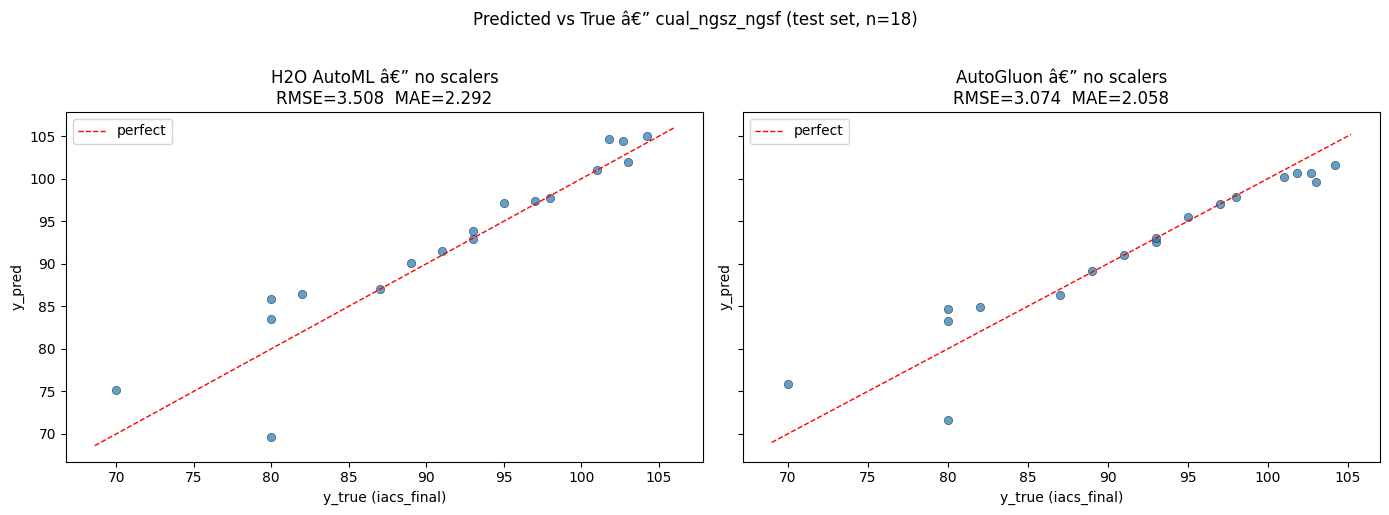

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, y_pred) in zip(
    axes,
    [("H2O AutoML", y_pred_h2o), ("AutoGluon", y_pred_agl)],
):
    ax.scatter(y_test, y_pred, alpha=0.7, edgecolors="k", linewidths=0.4)
    lims = [min(y_test.min(), y_pred.min()) - 1,
            max(y_test.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, "r--", linewidth=1, label="perfect")
    ax.set_xlabel("y_true (iacs_final)")
    ax.set_ylabel("y_pred")
    ax.set_title(f"{label} â€” no scalers\nRMSE={evla.rmse(y_test, y_pred):.3f}  MAE={evla.mae(y_test, y_pred):.3f}")
    ax.legend()

plt.suptitle(f"Predicted vs True â€” {TAG} (test set, n={len(y_test)})", y=1.02)
plt.tight_layout()
plt.show()

---
## Error Analysis — OOF Error & Ensemble Disagreement

Symmetric analysis for both H2O and AutoGluon:
- **σ_oof**: absolute residual between ground truth and OOF prediction (uncertainty proxy for training data)
- **σ_ensemble**: std across top-K model predictions on the test set (between-model disagreement)

Framework-agnostic math layer — H2O / AGL adapters handle data extraction.

In [ ]:
# ── Core math functions (framework-agnostic) ───────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compute_sigma_oof(
    y_true: np.ndarray,
    oof_preds: np.ndarray,
) -> np.ndarray:
    """Absolute OOF residuals — shape (n_train,).

    Parameters
    ----------
    y_true : np.ndarray
        Ground-truth labels for the training split.
    oof_preds : np.ndarray
        Out-of-fold predictions aligned to y_true.

    Returns
    -------
    np.ndarray
        Per-row absolute residual (proxy for σ_oof).
    """
    return np.abs(y_true - oof_preds)


def compute_sigma_ensemble(
    top_k_preds: np.ndarray,
) -> np.ndarray:
    """Row-wise std across top-K model predictions — shape (n_test,).

    Parameters
    ----------
    top_k_preds : np.ndarray
        Shape (top_k, n_test). Each row is one model's predictions.

    Returns
    -------
    np.ndarray
        Per-sample standard deviation across models.
    """
    return top_k_preds.std(axis=0)


In [ ]:
# ── H2O adapters ────────────────────────────────────────────────────


def get_oof_preds_h2o(aml) -> np.ndarray:
    """Retrieve OOF predictions from H2O AutoML leader.

    Requires AutoML was trained with
    ``keep_cross_validation_predictions=True``.

    Parameters
    ----------
    aml : h2o.automl.H2OAutoML
        Fitted AutoML object.

    Returns
    -------
    np.ndarray, shape (n_train,)
    """
    return (
        aml.leader
        .cross_validation_holdout_predictions()
        .as_data_frame()
        .iloc[:, 0]
        .to_numpy()
    )


def get_top_k_preds_h2o(
    aml,
    hf_test,
    top_k: int = 5,
) -> np.ndarray:
    """Predict with each of the top-K leaderboard models.

    Parameters
    ----------
    aml : h2o.automl.H2OAutoML
        Fitted AutoML object.
    hf_test : h2o.H2OFrame
        Test features (no label column).
    top_k : int
        Number of top models to include.

    Returns
    -------
    np.ndarray, shape (top_k, n_test)
    """
    lb = aml.leaderboard.as_data_frame()
    model_ids = lb["model_id"].tolist()[:top_k]
    preds = []
    for mid in model_ids:
        m = h2o.get_model(mid)
        p = m.predict(hf_test).as_data_frame().iloc[:, 0].to_numpy()
        preds.append(p)
    return np.array(preds)


In [ ]:
# ── AutoGluon adapters ──────────────────────────────────────────────


def get_oof_preds_agl(predictor) -> np.ndarray:
    """Retrieve OOF predictions from a fitted AutoGluon predictor.

    Parameters
    ----------
    predictor : autogluon.tabular.TabularPredictor
        Fitted predictor.

    Returns
    -------
    np.ndarray, shape (n_train,)
    """
    return predictor.predict_oof().to_numpy()


def get_top_k_preds_agl(
    predictor,
    df_test_feats: pd.DataFrame,
    top_k: int = 5,
) -> np.ndarray:
    """Predict with each of the top-K leaderboard models.

    Parameters
    ----------
    predictor : autogluon.tabular.TabularPredictor
        Fitted predictor.
    df_test_feats : pd.DataFrame
        Test features (no label column).
    top_k : int
        Number of top models to include.

    Returns
    -------
    np.ndarray, shape (top_k, n_test)
    """
    lb = predictor.leaderboard(silent=True)
    top_k_names = lb.head(top_k)["model"].tolist()
    preds = [
        predictor.predict(df_test_feats, model=name).to_numpy()
        for name in top_k_names
    ]
    return np.array(preds)


In [ ]:
# ── Orchestrator ────────────────────────────────────────────────────

ADAPTER_REGISTRY = {
    "h2o": {
        "get_oof": get_oof_preds_h2o,
        "get_top_k": get_top_k_preds_h2o,
    },
    "agl": {
        "get_oof": get_oof_preds_agl,
        "get_top_k": get_top_k_preds_agl,
    },
}


def run_error_analysis(
    framework: str,
    model_or_predictor,
    y_train: np.ndarray,
    test_input,
    top_k: int = 5,
    label: str = "",
) -> dict:
    """Run OOF and ensemble error analysis for one framework.

    Parameters
    ----------
    framework : {"h2o", "agl"}
        Which adapter set to use.
    model_or_predictor : H2OAutoML | TabularPredictor
        Fitted model object.
    y_train : np.ndarray
        Ground-truth labels for the training split (for OOF residuals).
    test_input : H2OFrame | pd.DataFrame
        Test features passed to the top-K predictor.
    top_k : int
        Number of top leaderboard models for ensemble disagreement.
    label : str
        Human-readable name used in plots and summary tables.

    Returns
    -------
    dict with keys:
        label, oof_preds, sigma_oof, top_k_preds, sigma_ensemble
    """
    if framework not in ADAPTER_REGISTRY:
        raise ValueError(
            f"Unknown framework {framework!r}. "
            f"Choose from {list(ADAPTER_REGISTRY)}"
        )
    adapters = ADAPTER_REGISTRY[framework]

    oof_preds = adapters["get_oof"](model_or_predictor)
    sigma_oof = compute_sigma_oof(y_train, oof_preds)

    top_k_preds = adapters["get_top_k"](model_or_predictor, test_input, top_k)
    sigma_ensemble = compute_sigma_ensemble(top_k_preds)

    return {
        "label": label or framework,
        "oof_preds": oof_preds,
        "sigma_oof": sigma_oof,
        "top_k_preds": top_k_preds,
        "sigma_ensemble": sigma_ensemble,
    }


In [ ]:
# ── Visualization helpers ────────────────────────────────────────────


def plot_error_comparison(results_list: list, bins: int = 20) -> None:
    """Side-by-side histograms of σ_oof and σ_ensemble per framework.

    Parameters
    ----------
    results_list : list[dict]
        Each dict is the output of ``run_error_analysis``.
    bins : int
        Number of histogram bins.
    """
    n = len(results_list)
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 8), sharey='row')
    if n == 1:
        axes = axes.reshape(2, 1)

    colors = ["steelblue", "darkorange", "seagreen", "crimson"]

    for col, res in enumerate(results_list):
        color = colors[col % len(colors)]
        lbl = res["label"]

        # Row 0 — σ_oof
        ax = axes[0, col]
        ax.hist(res["sigma_oof"], bins=bins, color=color,
                alpha=0.75, edgecolor="white")
        ax.axvline(res["sigma_oof"].mean(), color="black", ls="--",
                   label=f"mean={res['sigma_oof'].mean():.4f}")
        ax.set_title(f"{lbl} — σ_oof (train)")
        ax.set_xlabel("Absolute OOF residual")
        ax.legend(fontsize=8)

        # Row 1 — σ_ensemble
        ax = axes[1, col]
        ax.hist(res["sigma_ensemble"], bins=bins, color=color,
                alpha=0.75, edgecolor="white")
        ax.axvline(res["sigma_ensemble"].mean(), color="black", ls="--",
                   label=f"mean={res['sigma_ensemble'].mean():.4f}")
        ax.set_title(f"{lbl} — σ_ensemble (test)")
        ax.set_xlabel("Ensemble std")
        ax.legend(fontsize=8)

    for ax in axes[:, 0]:
        ax.set_ylabel("Count")

    fig.suptitle(
        "Error distribution — OOF residual vs Ensemble disagreement",
        fontsize=13, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()


def summarize_errors_table(results_list: list) -> pd.DataFrame:
    """Summary statistics (mean, median, p95) for σ_oof and σ_ensemble.

    Parameters
    ----------
    results_list : list[dict]
        Each dict is the output of ``run_error_analysis``.

    Returns
    -------
    pd.DataFrame
        Multi-index (framework, sigma), columns = mean/median/p95/max.
    """
    records = []
    for res in results_list:
        for sigma_name in ("sigma_oof", "sigma_ensemble"):
            arr = res[sigma_name]
            records.append({
                "framework": res["label"],
                "sigma": sigma_name,
                "mean": arr.mean(),
                "median": float(np.median(arr)),
                "p95": float(np.percentile(arr, 95)),
                "max": arr.max(),
            })
    df = pd.DataFrame(records).set_index(["framework", "sigma"])
    return df.round(5)


In [ ]:
# ── Run error analysis for both frameworks ──────────────────────────

TOP_K = 5

y_train_np = df_train[TARGET].to_numpy()

# H2O: test input must be an H2OFrame (features only)
hf_test_feats = h2o.H2OFrame(df_test[FEATURES])

results_h2o = run_error_analysis(
    framework="h2o",
    model_or_predictor=aml_h2o,
    y_train=y_train_np,
    test_input=hf_test_feats,
    top_k=TOP_K,
    label="H2O AutoML",
)

# AutoGluon: test input is a plain DataFrame (features only)
results_agl = run_error_analysis(
    framework="agl",
    model_or_predictor=predictor_agl,
    y_train=y_train_np,
    test_input=df_test[FEATURES],
    top_k=TOP_K,
    label="AutoGluon",
)

results_all = [results_h2o, results_agl]
print("Error analysis complete.")


NameError: name 'TARGET' is not defined

In [ ]:
# ── Summary table ───────────────────────────────────────────────────

df_errors = summarize_errors_table(results_all)
display(
    df_errors.style
    .highlight_min(axis=0, color='lightgreen')
    .format('{:.5f}')
    .set_caption('Error summary — lower is better')
)


In [ ]:
# ── Distribution plots ──────────────────────────────────────────────

plot_error_comparison(results_all, bins=15)
